# Envirotype Analysis: Do different environments need different corn lines?

**Question:** If we group the test environments by their conditions (dry, wet, hot, cool, soil type, nitrogen), do the best lines change from group to group?

**Why it matters:** If yes, we should recommend different lines for different kinds of environments (Challenge 2). If no, one broad ranking is enough (Challenge 1).

**Roadmap**
1. Understand the environmental file (what all those columns are)
2. Choose the soil variables we use, and why
3. Check data quality
4. Build weather variables that matter for corn
5. Cluster environments into weather types and soil types
6. Do the types yield differently?
7. Do the best lines change between types? (the key test)
8. Do the best parents change between types?
9. Conclusions

**Rule we follow:** we only use 2001 to 2007 to learn anything. The 2008 data is the answer key and is not used here.

**Before running:** this notebook sits in the `analysis` folder next to `Simplified Hackathon Dataset V3`. It needs pandas, numpy, matplotlib and scikit-learn (`pip install pandas numpy matplotlib scikit-learn`). Reading the two big phenotype files takes about a minute.

In [2]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

DATA = os.path.join('..', 'Simplified Hackathon Dataset V3')
OUT = 'outputs'; os.makedirs(OUT, exist_ok=True)
HIST = (2001, 2007)

# chart style: thin marks, quiet grid, fixed color order
COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
INK, MUTED = '#0b0b0b', '#898781'
plt.rcParams.update({'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True, 'grid.color': '#e6e5e0',
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'legend.frameon': False, 'axes.axisbelow': True})

## 1. What is in the environmental file?

There is one row per **year + location** (called an *environment*). It has 84 variables, and they come in two families:

| Family | How many | Built from |
|---|---|---|
| Weather | 42 | 6 measurements x 7 months (April to October) |
| Soil | 42 | 7 properties x 6 depths |

That's why there are so many soil columns: each soil property is repeated for 6 depth layers. The table below shows the grid.

In [3]:
env_raw = pd.read_csv(os.path.join(DATA, 'environmental_features.csv'), encoding='utf-8-sig')
weather_cols = [c for c in env_raw.columns if c.startswith('X')]
soil_cols = [c for c in env_raw.columns if c not in weather_cols + ['YEAR', 'LOC']]
print(f'{len(env_raw)} environments, {len(weather_cols)} weather columns, {len(soil_cols)} soil columns')

props = ['clay', 'silt', 'sand', 'soc', 'nitrogen', 'phh2o', 'cfvo']
depths = ['0_5cm', '5_15cm', '15_30cm', '30_60cm', '60_100cm', '100_200cm']
used = {('clay', d) for d in depths[:5]} | {(p, d) for p in ['sand', 'soc', 'nitrogen', 'phh2o', 'cfvo'] for d in depths[:3]}
grid = pd.DataFrame([['USED' if (p, d) in used else 'dropped' for d in depths] for p in props], index=props, columns=depths)
grid

1185 environments, 42 weather columns, 42 soil columns


,0_5cm,5_15cm,15_30cm,30_60cm,60_100cm,100_200cm
clay,USED,USED,USED,USED,USED,dropped
silt,dropped,dropped,dropped,dropped,dropped,dropped
sand,USED,USED,USED,dropped,dropped,dropped
soc,USED,USED,USED,dropped,dropped,dropped
nitrogen,USED,USED,USED,dropped,dropped,dropped
phh2o,USED,USED,USED,dropped,dropped,dropped
cfvo,USED,USED,USED,dropped,dropped,dropped


## 2. Which soil variables we use, and why

### The 7 soil properties

| Column prefix | What it is | Raw unit, and how to convert | Why it matters for corn |
|---|---|---|---|
| `clay` | Share of very fine particles | per mille; divide by 10 to get % | Holds water and nutrients; very high clay drains poorly |
| `silt` | Share of medium particles | per mille; divide by 10 to get % | Good water holding |
| `sand` | Share of coarse particles | per mille; divide by 10 to get % | Drains fast; sandy soils dry out in drought |
| `soc` | Soil organic carbon | dg/kg; divide by 10 to get g/kg | Organic matter: fertility, structure, water holding |
| `nitrogen` | Total nitrogen | cg/kg; divide by 100 to get g/kg | Corn's main nutrient |
| `phh2o` | Soil pH | pH x 10; divide by 10 | Corn likes pH 6 to 7; acidic soil limits nutrients |
| `cfvo` | Coarse fragments (gravel, stones) | per mille by volume; divide by 10 to get % | Less space for roots and water |

### What we keep, and what we drop

**1. Combine the three shallow layers into one "topsoil" value (0 to 30 cm).** Most corn roots and most of the nitrogen are here. We take a depth-weighted average: the 0 to 5 cm layer counts 5 parts, 5 to 15 cm counts 10 parts, and 15 to 30 cm counts 15 parts, because thicker layers hold more soil.

**2. Keep only clay for the "subsoil" (30 to 100 cm).** Deeper clay decides how much water is stored for the roots in July and August.

**3. Drop the 100 to 200 cm layer.** It is below most of the active root zone.

**4. Drop silt.** Clay + silt + sand always adds to 100%, so silt adds no new information once we have clay and sand.

**Result:** 42 soil columns become **7 variables**:

| Our variable | Built from |
|---|---|
| `Clay_top_pct` | clay 0-5, 5-15, 15-30 cm |
| `Sand_top_pct` | sand 0-5, 5-15, 15-30 cm |
| `SOC_top_gkg` | soc 0-5, 5-15, 15-30 cm |
| `N_top_gkg` | nitrogen 0-5, 5-15, 15-30 cm |
| `pH_top` | phh2o 0-5, 5-15, 15-30 cm |
| `Coarse_top_pct` | cfvo 0-5, 5-15, 15-30 cm |
| `Clay_sub_pct` | clay 30-60, 60-100 cm |

In [4]:
def topsoil(e, v):   # depth-weighted average of 0-5, 5-15, 15-30 cm
    return (e[f'{v}_0_5cm'] * 5 + e[f'{v}_5_15cm'] * 10 + e[f'{v}_15_30cm'] * 15) / 30
def subsoil(e, v):   # depth-weighted average of 30-60, 60-100 cm
    return (e[f'{v}_30_60cm'] * 30 + e[f'{v}_60_100cm'] * 40) / 70

soil = env_raw[['YEAR', 'LOC']].copy()
soil['Clay_top_pct']   = topsoil(env_raw, 'clay') / 10
soil['Sand_top_pct']   = topsoil(env_raw, 'sand') / 10
soil['SOC_top_gkg']    = topsoil(env_raw, 'soc') / 10
soil['N_top_gkg']      = topsoil(env_raw, 'nitrogen') / 100
soil['pH_top']         = topsoil(env_raw, 'phh2o') / 10
soil['Coarse_top_pct'] = topsoil(env_raw, 'cfvo') / 10
soil['Clay_sub_pct']   = subsoil(env_raw, 'clay') / 10
SOIL = [c for c in soil.columns if c not in ('YEAR', 'LOC')]

# example: one location, raw columns vs our readable version
ex = env_raw.iloc[0]
print('Example environment:', ex.LOC, ex.YEAR)
print('Raw clay by depth (per mille):', {d: ex[f'clay_{d}'] for d in depths})
soil.iloc[[0]].round(1)

Example environment: SDEP 2001
Raw clay by depth (per mille): {'0_5cm': 388.0, '5_15cm': 393.0, '15_30cm': 366.0, '30_60cm': 351.0, '60_100cm': 360.0, '100_200cm': 347.0}


,YEAR,LOC,Clay_top_pct,Sand_top_pct,SOC_top_gkg,N_top_gkg,pH_top,Coarse_top_pct,Clay_sub_pct
0,2001,SDEP,37.9,19.5,17.4,1.7,7.0,0.3,35.6


## 3. Data quality check: a lot of soil data is filled in, not measured

If a location had no soil data, someone filled every soil column with the **same average value**. Those rows look normal but carry no real information. We detect them: a row is "filled" if more than 80% of its soil columns equal the most common value.

In [5]:
mode = env_raw[soil_cols].mode().iloc[0]
soil['soil_filled'] = (env_raw[soil_cols] == mode).mean(axis=1) > 0.8
print(f"Environments with filled-in (not measured) soil data: {soil.soil_filled.mean():.0%}")
print('The filled value for clay 0-5 cm is', mode['clay_0_5cm'], '(a non-integer average; real measurements are whole numbers)')

Environments with filled-in (not measured) soil data: 38%
The filled value for clay 0-5 cm is 288.0217984 (a non-integer average; real measurements are whole numbers)


**Decision:** we cluster soil **only on locations with real measurements**. The others are labeled "Soil unknown".

We also found a few months with 0 mm rain **and** 0 rainy days. That's almost certainly a missing station record, so we treat it as missing.

## 4. Weather variables that matter for corn

The 42 weather columns are 6 measurements for each month from April (`X04`) to October (`X10`):

| Suffix | Meaning |
|---|---|
| `PRCP` | Total rain in the month (mm) |
| `TAVG` | Average temperature (C) |
| `DP01` | Days with any measurable rain |
| `DP10` | Days with at least 0.1 inch of rain |
| `HTDD` | Heating degree days (how cold) |
| `CLDD` | Cooling degree days (how hot) |

We don't use all 42 directly. We turn them into 9 variables tied to corn's growth stages:

| Variable | Months | Why |
|---|---|---|
| `GDD_MaySep` | May to Sep | **Growing degree days** (heat accumulated above 10 C). Measures season length; decides if a hybrid can mature |
| `Temp_JulAug` | Jul to Aug | Heat during **silking and grain fill**, the most sensitive stage |
| `Rain_JulAug` | Jul to Aug | Water during silking and grain fill |
| `WaterBal_JulAug` | Jul to Aug | Rain minus the crop's water demand (estimated from temperature). **Negative = drought stress** |
| `RainDays_JulAug` | Jul to Aug | Days with meaningful rain. How the rain is spread matters, not just the total |
| `Rain_Jun` | Jun | Water during fast vegetative growth |
| `Rain_AprMay` | Apr to May | Planting conditions (too wet delays planting) |
| `Temp_AprMay` | Apr to May | Cold springs slow emergence |
| `Rain_Sep` | Sep | Grain dry-down and harvest moisture |

Water demand uses the **Thornthwaite** formula, a standard way to estimate evaporation when you only have temperature.

In [6]:
DAYS = {'04': 30, '05': 31, '06': 30, '07': 31, '08': 31, '09': 30, '10': 31}
e = env_raw.copy()
for m in DAYS:   # 0 rain with 0 rainy days = missing record
    e.loc[(e[f'X{m}_PRCP'] == 0) & (e[f'X{m}_DP01'] == 0), f'X{m}_PRCP'] = np.nan
T = {m: e[f'X{m}_TAVG'] for m in DAYS}
P = {m: e[f'X{m}_PRCP'] for m in DAYS}

# Thornthwaite potential evapotranspiration (crop water demand), mm per month
I = sum((T[m].clip(lower=0) / 5) ** 1.514 for m in DAYS)
a = 6.75e-7 * I**3 - 7.71e-5 * I**2 + 1.792e-2 * I + 0.49239
PET = {m: 16 * (10 * T[m].clip(lower=0) / I) ** a * DAYS[m] / 30 for m in DAYS}

weather = e[['YEAR', 'LOC']].copy()
weather['GDD_MaySep']      = sum((T[m] - 10).clip(lower=0) * DAYS[m] for m in ['05', '06', '07', '08', '09'])
weather['Temp_JulAug']     = (T['07'] + T['08']) / 2
weather['Rain_JulAug']     = P['07'] + P['08']
weather['WaterBal_JulAug'] = weather.Rain_JulAug - (PET['07'] + PET['08'])
weather['RainDays_JulAug'] = e.X07_DP10 + e.X08_DP10
weather['Rain_Jun']        = P['06']
weather['Rain_AprMay']     = P['04'] + P['05']
weather['Temp_AprMay']     = (T['04'] + T['05']) / 2
weather['Rain_Sep']        = P['09']
WEATHER = [c for c in weather.columns if c not in ('YEAR', 'LOC')]

feat = weather.merge(soil, on=['YEAR', 'LOC'])
feat[WEATHER].describe().round(1).T[['mean', 'min', '50%', 'max']]

,mean,min,50%,max
GDD_MaySep,1589.8,986.7,1569.8,2538.2
Temp_JulAug,23.1,18.2,23.0,29.2
Rain_JulAug,194.8,21.8,189.4,710.7
WaterBal_JulAug,-41.6,-256.1,-45.8,438.7
RainDays_JulAug,11.7,1.0,11.6,28.0
Rain_Jun,105.1,6.7,99.5,354.7
Rain_AprMay,192.4,33.7,189.9,497.8
Temp_AprMay,13.4,7.2,13.4,22.3
Rain_Sep,92.8,0.8,89.1,341.0


## 5. Cluster the environments

**K-means clustering** puts environments with similar numbers into the same group. Two details:

- **Scaling first.** Rain in mm and temperature in C have very different ranges. We rescale each variable so none dominates just because of its units.
- **Weather and soil clustered separately.** Weather changes every year at the same location, but soil does not. Mixing them would blur both.

### 5a. Weather types

We fit on 2001 to 2007 only. The *silhouette score* measures how cleanly separated the groups are (1 = perfect, 0 = overlapping). Weather scores are low for every number of groups, because weather is a continuum rather than neat blobs. So we pick **4 groups**, the number with the clearest agronomic meaning.

In [7]:
hist = feat[(feat.YEAR >= HIST[0]) & (feat.YEAR <= HIST[1])].dropna(subset=WEATHER).copy()
scaler_w = StandardScaler().fit(hist[WEATHER]); Xw = scaler_w.transform(hist[WEATHER])
print('Silhouette by number of groups:', {k: round(silhouette_score(Xw, KMeans(k, n_init=20, random_state=0).fit_predict(Xw)), 3) for k in range(3, 7)})

km_w = KMeans(4, n_init=20, random_state=0).fit(Xw)
hist['W_id'] = km_w.labels_
prof = hist.groupby('W_id')[WEATHER].mean()
z = (prof - hist[WEATHER].mean()) / hist[WEATHER].std()   # how far each group sits from the overall average

def name_weather(r):   # name each group from its profile
    if r.GDD_MaySep > 1.2: return 'Hot, long season (southern)'
    if r.WaterBal_JulAug < -0.5: return 'Dry summer'
    if r.WaterBal_JulAug > 0.5: return 'Wet summer'
    if r.Temp_JulAug < -0.5: return 'Cool summer, short season'
    return 'Average summer'
wnames = {i: name_weather(z.loc[i]) for i in z.index}
hist['Weather_type'] = hist.W_id.map(wnames)
WTYPES = ['Cool summer, short season', 'Dry summer', 'Wet summer', 'Hot, long season (southern)']
WCOL = dict(zip(WTYPES, COLORS))

table = hist.groupby('Weather_type')[WEATHER].mean().reindex(WTYPES)
table['n_environments'] = hist.Weather_type.value_counts()
table.round(1).T

  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Silhouette by number of groups: {3: 0.189, 4: 0.178, 5: 0.158, 6: 0.167}


Weather_type,"Cool summer, short season",Dry summer,Wet summer,"Hot, long season (southern)"
GDD_MaySep,1378.3,1694.3,1583.0,2107.8
Temp_JulAug,21.7,24.0,22.8,26.4
Rain_JulAug,178.2,146.0,271.0,260.0
WaterBal_JulAug,-42.4,-100.7,38.7,-17.7
RainDays_JulAug,11.2,9.9,14.6,13.6
Rain_Jun,115.2,82.1,87.3,118.3
Rain_AprMay,191.9,188.4,192.0,194.3
Temp_AprMay,11.7,14.1,13.6,18.6
Rain_Sep,88.9,87.1,88.8,111.7
n_environments,264.0,321.0,260.0,79.0


**How to read it:** each column is a weather type, and each row is the average of one variable in that type.

- **Dry summer** has the biggest water deficit (about -100 mm).
- **Wet summer** has a surplus.
- **Cool, short season** has the fewest growing degree days.
- **Hot, long season** stands out mostly by heat and season length. These are the southern sites.

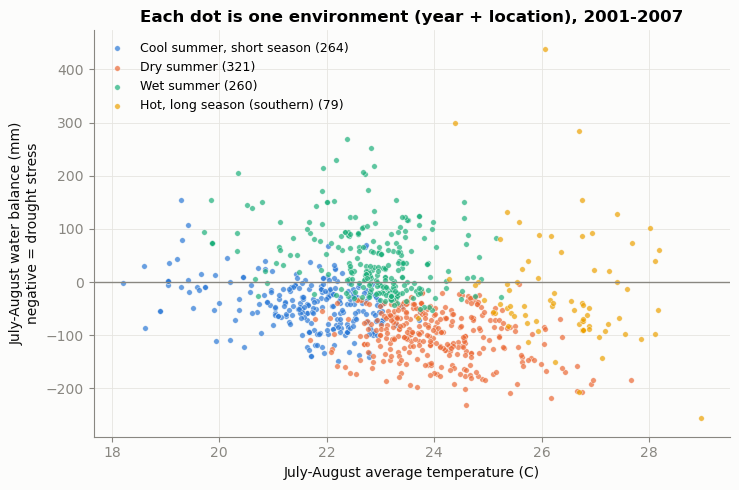

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for t in WTYPES:
    s = hist[hist.Weather_type == t]
    ax.scatter(s.Temp_JulAug, s.WaterBal_JulAug, s=16, alpha=0.7, color=WCOL[t], label=f'{t} ({len(s)})', edgecolors='#fcfcfb', linewidths=0.4)
ax.axhline(0, color=MUTED, lw=1)
ax.set_xlabel('July-August average temperature (C)'); ax.set_ylabel('July-August water balance (mm)\nnegative = drought stress')
ax.set_title('Each dot is one environment (year + location), 2001-2007')
ax.legend(loc='upper left', fontsize=9); plt.tight_layout(); plt.show()

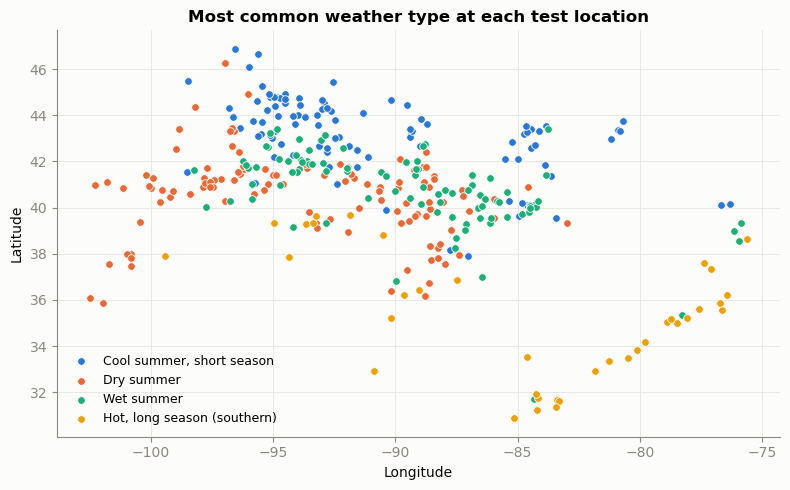

In [9]:
# where are the types? most frequent weather type per location
ll = pd.concat([pd.read_csv(os.path.join(DATA, f'C{c}_Phenotype_Data_V2.csv'), usecols=['LOC', 'LATITUDE', 'LONGITUDE'])
                for c in (1, 2)]).groupby('LOC').first()
dom = hist.groupby('LOC').Weather_type.agg(lambda x: x.value_counts().index[0]).to_frame().join(ll)
fig, ax = plt.subplots(figsize=(8, 5))
for t in WTYPES:
    s = dom[dom.Weather_type == t]
    ax.scatter(s.LONGITUDE, s.LATITUDE, s=30, color=WCOL[t], label=t, edgecolors='#fcfcfb', linewidths=0.6)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_title('Most common weather type at each test location')
ax.legend(fontsize=9, loc='lower left'); plt.tight_layout(); plt.show()

The map makes sense: the cool, short-season type sits in the north (MN, WI), the hot type in the south (MO, GA, NC), and dry and wet summers fall across the central Corn Belt. A location in Iowa can be dry one year and wet the next, which is why weather types are assigned per year + location.

### 5b. Soil types (locations with real soil data only)

In [10]:
loc_soil = feat[~feat.soil_filled].drop_duplicates('LOC')[['LOC'] + SOIL].copy()
scaler_s = StandardScaler().fit(loc_soil[SOIL]); Xs = scaler_s.transform(loc_soil[SOIL])
print('Silhouette by number of groups:', {k: round(silhouette_score(Xs, KMeans(k, n_init=20, random_state=0).fit_predict(Xs)), 3) for k in range(3, 6)})
km_s = KMeans(3, n_init=20, random_state=0).fit(Xs)
loc_soil['S_id'] = km_s.labels_
zs = (loc_soil.groupby('S_id')[SOIL].mean() - loc_soil[SOIL].mean()) / loc_soil[SOIL].std()
def name_soil(r):
    if r.Sand_top_pct > 0.8: return 'Sandy, low water holding'
    if r.SOC_top_gkg > 0.8 or r.N_top_gkg > 0.8: return 'High organic matter / high N'
    return 'Silt-loam, typical'
loc_soil['Soil_type'] = loc_soil.S_id.map({i: name_soil(zs.loc[i]) for i in zs.index})
st = loc_soil.groupby('Soil_type')[SOIL].mean(); st['n_locations'] = loc_soil.Soil_type.value_counts()
st.round(2).T

Silhouette by number of groups: {3: 0.328, 4: 0.256, 5: 0.272}


Soil_type,High organic matter / high N,"Sandy, low water holding","Silt-loam, typical"
Clay_top_pct,29.43,20.11,32.85
Sand_top_pct,28.92,47.25,12.54
SOC_top_gkg,31.53,20.25,18.47
N_top_gkg,3.96,1.95,2.06
pH_top,6.77,5.92,6.37
Coarse_top_pct,3.27,1.54,0.95
Clay_sub_pct,30.26,24.43,34.73
n_locations,55.00,52.00,140.00


Three soil types come out: **typical silt-loam** (most locations), **sandy** (drains fast, lower pH, less nitrogen), and **high organic matter / high nitrogen**.

## 6. Do the types actually yield differently?

We need the yield data now. To remove whole-year effects (some years are good everywhere), we compare each environment's average yield with the average of **its own year**.

847,710 plots in 923 environments


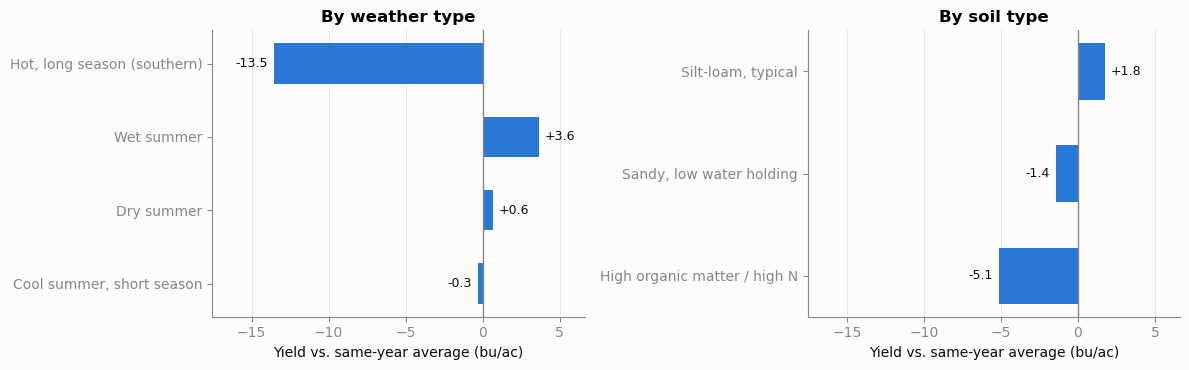

In [11]:
cols = ['YEAR_x', 'LOC', 'YLD_BE', 'LINE_UNIQUE_ID', 'shorthand_x', 'CROSS', 'CLUSTER']
pheno = pd.concat([pd.read_csv(os.path.join(DATA, f'C{c}_Phenotype_Data_V2.csv'), usecols=cols, low_memory=False) for c in (1, 2)])
pheno = pheno.rename(columns={'YEAR_x': 'YEAR', 'shorthand_x': 'POP'})
h = pheno[(pheno.YEAR >= HIST[0]) & (pheno.YEAR <= HIST[1])].dropna(subset=['YLD_BE'])
h = h.merge(hist[['YEAR', 'LOC', 'Weather_type']], on=['YEAR', 'LOC']).merge(loc_soil[['LOC', 'Soil_type']], on='LOC', how='left')
h['Soil_type'] = h.Soil_type.fillna('Soil unknown')
h['env'] = h.YEAR.astype(str) + '_' + h.LOC
# each plot's yield relative to its environment's average (its "advantage")
h['dev'] = h.YLD_BE - h.groupby('env').YLD_BE.transform('mean')
print(f'{len(h):,} plots in {h.env.nunique()} environments')

em = h.groupby(['env', 'YEAR', 'Weather_type', 'Soil_type']).YLD_BE.mean().reset_index()
em['vs_year'] = em.YLD_BE - em.groupby('YEAR').YLD_BE.transform('mean')
w_eff = em.groupby('Weather_type').vs_year.mean().reindex(WTYPES)
s_eff = em[em.Soil_type != 'Soil unknown'].groupby('Soil_type').vs_year.mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
lo, hi = min(w_eff.min(), s_eff.min()) - 4, max(w_eff.max(), s_eff.max()) + 3
for ax, eff, title in [(axes[0], w_eff, 'By weather type'), (axes[1], s_eff, 'By soil type')]:
    ax.barh(eff.index, eff.values, color=COLORS[0], height=0.55)
    ax.axvline(0, color=MUTED, lw=1)
    for i, v in enumerate(eff.values):
        ax.text(v + (0.4 if v >= 0 else -0.4), i, f'{v:+.1f}', va='center', ha='left' if v >= 0 else 'right', color=INK, fontsize=9)
    ax.set_xlim(lo, hi); ax.set_title(title); ax.set_xlabel('Yield vs. same-year average (bu/ac)'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

Southern hot environments yield about 13 bu/ac less than average for their year, and wet summers slightly more. The groups capture something real about **how much** an environment yields.

But that alone doesn't matter for choosing lines: if every line drops 13 bushels, the ranking stays the same. What matters is whether the **ranking** changes, which is the next test.

## 7. The key test: do the best lines change between weather types?

**Idea:** take a population tested in, say, both dry-summer and wet-summer sites.

1. Compute each line's average **advantage** (yield minus the site average) in the dry sites.
2. Compute the same in the wet sites.
3. Correlate the two lists. A high correlation means the same lines win in both.

**The catch:** each line has only one plot per site, so even two random groups of sites won't agree perfectly. We need a **fair baseline**: split the same sites into two *random* groups of the same sizes and correlate again.

- If between-type agreement is about the same as random agreement, the types **don't change** the ranking.
- If it's clearly lower, the ranking **does** change (G x E).

**Example:** Line 7 scores +15 in dry sites and +14 in wet sites, and Line 12 scores -5 and -6. That's no G x E. If Line 7 were +15 in dry sites but -3 in wet ones, that would be G x E.

In [12]:
def gxe_test(d, col, seed=0, min_env=3, min_lines=20, reps=5):
    rng = np.random.default_rng(seed); out = []
    for pop, g in d.groupby('POP'):
        n_env = g.drop_duplicates('env').groupby(col).env.nunique()
        types = n_env[n_env >= min_env].sort_values(ascending=False).index.tolist()
        if len(types) < 2: continue                     # needs 3+ sites in each of two types
        a, b = types[:2]
        m = g[g[col].isin([a, b])].pivot_table(index='LINE_UNIQUE_ID', columns=col, values='dev', aggfunc='mean').dropna()
        if len(m) < min_lines: continue
        between = np.corrcoef(m[a], m[b])[0, 1]
        envs = g[g[col].isin([a, b])].drop_duplicates('env').env.values
        rand = []
        for _ in range(reps):                           # random split of the same sites, same group sizes
            p = rng.permutation(envs)
            A = g[g.env.isin(p[:n_env[a]])].groupby('LINE_UNIQUE_ID').dev.mean()
            B = g[g.env.isin(p[n_env[a]:])].groupby('LINE_UNIQUE_ID').dev.mean()
            j = A.index.intersection(B.index); rand.append(np.corrcoef(A[j], B[j])[0, 1])
        out.append(dict(POP=pop, cluster=f'C{g.CLUSTER.iloc[0]}', pair=f'{a} vs {b}', between=between, random=np.mean(rand)))
    return pd.DataFrame(out)

gw = gxe_test(h, 'Weather_type')
summary = gw.groupby('cluster').agg(between_types=('between', 'mean'), random_split=('random', 'mean'), populations=('POP', 'size'))
summary['gap'] = summary.random_split - summary.between_types
summary['gap_se'] = gw.assign(g=gw.random - gw.between).groupby('cluster').g.agg(lambda x: x.std() / np.sqrt(len(x)))
summary.round(3)

,between_types,random_split,populations,gap,gap_se
cluster,,,,,
C1,0.303,0.302,104,-0.000,0.006
C2,0.250,0.265,69,0.015,0.006


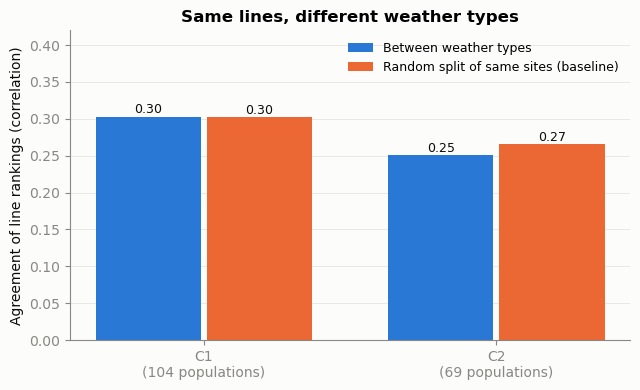

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(summary)); w = 0.36
b1 = ax.bar(x - w/2 - 0.01, summary.between_types, w, color=COLORS[0], label='Between weather types')
b2 = ax.bar(x + w/2 + 0.01, summary.random_split, w, color=COLORS[1], label='Random split of same sites (baseline)')
for bars in (b1, b2):
    for r in bars: ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.005, f'{r.get_height():.2f}', ha='center', fontsize=9, color=INK)
ax.set_xticks(x); ax.set_xticklabels([f'{c}\n({n} populations)' for c, n in zip(summary.index, summary.populations)])
ax.set_ylabel('Agreement of line rankings (correlation)'); ax.set_ylim(0, 0.42)
ax.set_title('Same lines, different weather types'); ax.legend(fontsize=9, loc='upper right'); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

**Result:**

- **C1:** agreement between weather types equals the random baseline, so the best lines don't change.
- **C2:** agreement is slightly lower (a gap of about 0.015, around 2.5 standard errors). That's a small, real effect.

The same test by **soil type** could only use a handful of populations, because populations are usually tested on one soil type:

In [14]:
gs = gxe_test(h[h.Soil_type != 'Soil unknown'], 'Soil_type')
gs.groupby('cluster').agg(between_types=('between', 'mean'), random_split=('random', 'mean'), populations=('POP', 'size')).round(3)

,between_types,random_split,populations
cluster,,,
C1,0.228,0.246,11
C2,0.168,0.196,6


## 8. Do the best parents change between weather types?

Lines are tested in only one year, but **parents are reused** across many populations and years. For each parent, we average the advantage of its offspring in each weather type, then check whether parent rankings agree between types.

Baseline again: shuffle the weather-type labels randomly across environments (keeping the group sizes), and recompute. If real agreement is lower than every shuffle, the types really do rerank parents.

Real agreement: 0.25   Shuffled baseline: 0.30 (range 0.27 to 0.34)


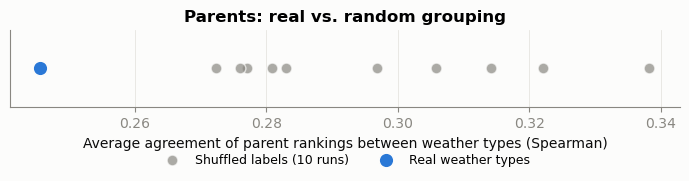

In [15]:
def parent_scores(h, labels):
    x = h.assign(W=h.env.map(labels))
    p = x.groupby(['POP', 'CLUSTER', 'CROSS', 'W']).dev.agg(['mean', 'size']).reset_index()
    p['parent'] = p.CROSS.astype(str).str.split('/'); p = p.explode('parent'); p['wsum'] = p['mean'] * p['size']
    g = p.groupby(['CLUSTER', 'parent', 'W'])[['wsum', 'size']].sum()
    g = g[g['size'] >= 100]; g['score'] = g.wsum / g['size']      # only parent x type combos with 100+ plots
    return g.score.unstack('W')

def mean_agreement(scores):
    vals = []
    for c in (1, 2):
        m = scores.loc[c].corr(method='spearman', min_periods=15).values
        vals += list(m[np.triu_indices_from(m, 1)])
    return np.nanmean(vals)

labels = h.drop_duplicates('env').set_index('env').Weather_type
real_scores = parent_scores(h, labels.to_dict())
real = mean_agreement(real_scores)
rng = np.random.default_rng(1)
shuffled = [mean_agreement(parent_scores(h, pd.Series(rng.permutation(labels.values), index=labels.index).to_dict())) for _ in range(10)]
print(f'Real agreement: {real:.2f}   Shuffled baseline: {np.mean(shuffled):.2f} (range {min(shuffled):.2f} to {max(shuffled):.2f})')

fig, ax = plt.subplots(figsize=(7, 2.4))
ax.scatter(shuffled, [0] * len(shuffled), s=60, color=MUTED, alpha=0.7, label='Shuffled labels (10 runs)', edgecolors='#fcfcfb')
ax.scatter([real], [0], s=110, color=COLORS[0], label='Real weather types', edgecolors='#fcfcfb', zorder=3)
ax.set_yticks([]); ax.set_xlabel('Average agreement of parent rankings between weather types (Spearman)')
ax.set_title('Parents: real vs. random grouping'); ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.45), ncol=2)
ax.grid(axis='y', visible=False); plt.tight_layout(); plt.show()

In [16]:
print('Parent ranking agreement between each pair of weather types:')
for c in (1, 2):
    print(f'\nCluster C{c}'); display(real_scores.loc[c][WTYPES].corr(method='spearman', min_periods=15).round(2))

Parent ranking agreement between each pair of weather types:

Cluster C1


W,"Cool summer, short season",Dry summer,Wet summer,"Hot, long season (southern)"
W,,,,
"Cool summer, short season",1.00,0.27,0.32,0.10
Dry summer,0.27,1.00,0.32,0.38
Wet summer,0.32,0.32,1.00,0.28
"Hot, long season (southern)",0.10,0.38,0.28,1.00



Cluster C2


W,"Cool summer, short season",Dry summer,Wet summer,"Hot, long season (southern)"
W,,,,
"Cool summer, short season",1.00,0.26,0.30,-0.14
Dry summer,0.26,1.00,0.37,0.14
Wet summer,0.30,0.37,1.00,0.35
"Hot, long season (southern)",-0.14,0.14,0.35,1.00


Real agreement falls below every shuffle, so there is a **modest real effect**. The tables show where: the lowest agreement is between **cool, short-season (north)** and **hot, long-season (south)**. That's a maturity and day-length adaptation story. Dry vs. wet summers barely rerank parents.

## 9. Conclusions

| Question | Answer |
|---|---|
| Are the weather and soil groups real? | Yes. They're geographically sensible, and southern hot sites yield about 13 bu/ac less |
| Do drought or wet summers change the best lines? | No, not detectably |
| Does soil change the best lines? | Can't tell: too few populations were tested on more than one soil type |
| Is there any G x E worth using? | A modest **north (cool, short) vs. south (hot, long)** effect, stronger in C2 |

**What this means for the model:**

1. Predict **broad-acre performance** as the main ranking (Challenge 1).
2. Add a **north/south adaptation score** for each line as a second output.
3. Give each 2008 location a **risk profile** from its 2001 to 2007 weather history. This is known in January, so there's no leakage.

**Data caveats to mention in the pitch:** 38% of environments have filled-in soil data, and the weather variables are monthly averages, which smooth out short heat or drought events.

In [17]:
# save results for the model and for Unity
all_env = feat.dropna(subset=WEATHER).copy()
all_env['Weather_type'] = pd.Series(km_w.predict(scaler_w.transform(all_env[WEATHER])), index=all_env.index).map(wnames)
all_env = all_env.merge(loc_soil[['LOC', 'Soil_type']], on='LOC', how='left'); all_env['Soil_type'] = all_env.Soil_type.fillna('Soil unknown')
all_env['note'] = np.where(all_env.YEAR == 2008, '2008: post hoc only, do not train', '')
all_env.to_csv(os.path.join(OUT, 'environment_envirotypes.csv'), index=False)

risk = pd.crosstab(hist.LOC, hist.Weather_type, normalize='index').reindex(columns=WTYPES, fill_value=0).round(2)
risk['years_seen'] = hist.groupby('LOC').YEAR.nunique()
risk = risk.join(ll).join(loc_soil.set_index('LOC').Soil_type)
risk['Soil_type'] = risk.Soil_type.fillna('Soil unknown')
risk['tested_2008'] = risk.index.isin(pheno[pheno.YEAR == 2008].LOC.unique())
risk.to_csv(os.path.join(OUT, 'location_weather_risk_profile.csv'))
real_scores.round(2).to_csv(os.path.join(OUT, 'parent_scores_by_weather_type.csv'))
print('Saved to', os.path.abspath(OUT)); risk.head()

Saved to c:\Users\Angel\Documents\Research\Hackaton\analysis\outputs


,"Cool summer, short season",Dry summer,Wet summer,"Hot, long season (southern)",years_seen,LONGITUDE,LATITUDE,Soil_type,tested_2008
LOC,,,,,,,,,
ARMA,0.0,0.00,0.00,1.00,3,-90.19,35.21,"Silt-loam, typical",False
ARPI,0.0,0.57,0.29,0.14,7,-90.18,36.37,"Sandy, low water holding",False
COOV,0.0,1.00,0.00,0.00,2,-102.30,40.96,"Sandy, low water holding",False
DESE,0.0,0.00,0.00,1.00,5,-75.61,38.64,Soil unknown,False
FLGR,0.0,0.00,0.00,1.00,1,-85.16,30.87,"Sandy, low water holding",False
